# Tensorflow Basics

In [6]:
import tensorflow as tf

In [7]:
scaler = tf.constant(9)
vector = tf.constant([4, 8, 10])
matrix = tf.constant([[4, 5], [10, 30], [80, 90]])

In [8]:
print('Scaler, Vector, and matrix')
print(scaler, vector, matrix)

Scaler, Vector, and matrix
tf.Tensor(9, shape=(), dtype=int32) tf.Tensor([ 4  8 10], shape=(3,), dtype=int32) tf.Tensor(
[[ 4  5]
 [10 30]
 [80 90]], shape=(3, 2), dtype=int32)


# Broadcasting

In [9]:
result = matrix * scaler
result

<tf.Tensor: shape=(3, 2), dtype=int32, numpy=
array([[ 36,  45],
       [ 90, 270],
       [720, 810]], dtype=int32)>

In [10]:
sum_result = matrix + [[2], [9], [2]]
sum_result

<tf.Tensor: shape=(3, 2), dtype=int32, numpy=
array([[ 6,  7],
       [19, 39],
       [82, 92]], dtype=int32)>

# Gradient

In [11]:
x = tf.Variable([4., 8., 9.])
with tf.GradientTape() as tape:
  tape.watch(x)
  y = x**2
dy_dx = tape.gradient(y, x)
print(dy_dx)

tf.Tensor([ 8. 16. 18.], shape=(3,), dtype=float32)


# Build a model using keras

In [12]:
from tensorflow import keras
from tensorflow.keras import layers

In [13]:
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()

In [14]:
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

In [24]:
model = keras.Sequential([
    keras.Input(shape=(32, 32, 3), name = 'Input layer'),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(32), # Removed activation from here
    layers.LeakyReLU(), # Added LeakyReLU as a separate layer
    layers.Dense(10, activation='softmax')
])

In [25]:
model.compile(
    loss = keras.losses.SparseCategoricalCrossentropy(),
    optimizer= keras.optimizers.Nadam(learning_rate= 0.001),
    metrics=['accuracy']
)

In [26]:
model.fit(x_train, y_train, batch_size = 64, epochs = 20, verbose = 2)


Epoch 1/20
782/782 - 6s - 7ms/step - accuracy: 0.2543 - loss: 2.0154
Epoch 2/20
782/782 - 2s - 2ms/step - accuracy: 0.2915 - loss: 1.9246
Epoch 3/20
782/782 - 2s - 3ms/step - accuracy: 0.3025 - loss: 1.8964
Epoch 4/20
782/782 - 2s - 2ms/step - accuracy: 0.3104 - loss: 1.8835
Epoch 5/20
782/782 - 2s - 2ms/step - accuracy: 0.3152 - loss: 1.8703
Epoch 6/20
782/782 - 2s - 2ms/step - accuracy: 0.3211 - loss: 1.8564
Epoch 7/20
782/782 - 2s - 3ms/step - accuracy: 0.3239 - loss: 1.8511
Epoch 8/20
782/782 - 2s - 2ms/step - accuracy: 0.3282 - loss: 1.8429
Epoch 9/20
782/782 - 2s - 2ms/step - accuracy: 0.3285 - loss: 1.8374
Epoch 10/20
782/782 - 2s - 2ms/step - accuracy: 0.3342 - loss: 1.8278
Epoch 11/20
782/782 - 2s - 2ms/step - accuracy: 0.3339 - loss: 1.8232
Epoch 12/20
782/782 - 2s - 2ms/step - accuracy: 0.3393 - loss: 1.8124
Epoch 13/20
782/782 - 2s - 3ms/step - accuracy: 0.3429 - loss: 1.8099
Epoch 14/20
782/782 - 2s - 2ms/step - accuracy: 0.3433 - loss: 1.8000
Epoch 15/20
782/782 - 2s - 2m

In [27]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)             │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │       196,672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 597,249 (2.28 MB)

 Trainable params: 199,082 (777.66 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 398,167 (1.52 MB)

In [28]:
model.evaluate(x_test, y_test, batch_size = 64, verbose = 2)

157/157 - 1s - 7ms/step - accuracy: 0.3829 - loss: 1.7599


[1.7598767280578613, 0.3828999996185303]

In [29]:
y_pred_probs = model.predict(x_test)
y_pred_labels = tf.argmax(y_pred_probs, axis=1)

print("Predicted Probabilities shape:", y_pred_probs.shape)
print("Predicted Labels shape:", y_pred_labels.shape)
print("First 5 predicted probabilities:\n", y_pred_probs[:5])
print("First 5 predicted labels:\n", y_pred_labels[:5])

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Predicted Probabilities shape: (10000, 10)
Predicted Labels shape: (10000,)
First 5 predicted probabilities:
 [[0.10006516 0.02928688 0.11051366 0.20692822 0.07647789 0.19663152
  0.08454352 0.05650314 0.1192525  0.01979761]
 [0.07900801 0.24989657 0.01181454 0.0431187  0.01055463 0.01943878
  0.00521973 0.01163215 0.15068166 0.4186352 ]
 [0.15160596 0.14694287 0.03087319 0.05952002 0.02224234 0.03518054
  0.00642218 0.02929343 0.33812094 0.17979856]
 [0.1584967  0.0425057  0.12596263 0.12461308 0.09751918 0.11561172
  0.07075027 0.06253489 0.15094054 0.05106528]
 [0.03105651 0.01216702 0.18698257 0.11220993 0.20278661 0.14015195
  0.18905249 0.10721105 0.00855424 0.00982771]]
First 5 predicted labels:
 tf.Tensor([3 9 8 0 4], shape=(5,), dtype=int64)


In [31]:
from sklearn.metrics import classification_report

# Ensure y_test is 1-dimensional for classification_report
y_true_labels = y_test.flatten()

# Calculate and display the classification report
report = classification_report(y_true_labels, y_pred_labels)
print("Classification Report:")
print(report)

Classification Report:
              precision    recall  f1-score   support

           0       0.53      0.38      0.44      1000
           1       0.57      0.52      0.54      1000
           2       0.30      0.18      0.23      1000
           3       0.16      0.20      0.18      1000
           4       0.33      0.25      0.28      1000
           5       0.33      0.34      0.34      1000
           6       0.31      0.57      0.41      1000
           7       0.46      0.46      0.46      1000
           8       0.58      0.39      0.47      1000
           9       0.45      0.53      0.48      1000

    accuracy                           0.38     10000
   macro avg       0.40      0.38      0.38     10000
weighted avg       0.40      0.38      0.38     10000



/tmp/ipython-input-607714084.py:25: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', n_classes) # Get a colormap for distinct colors


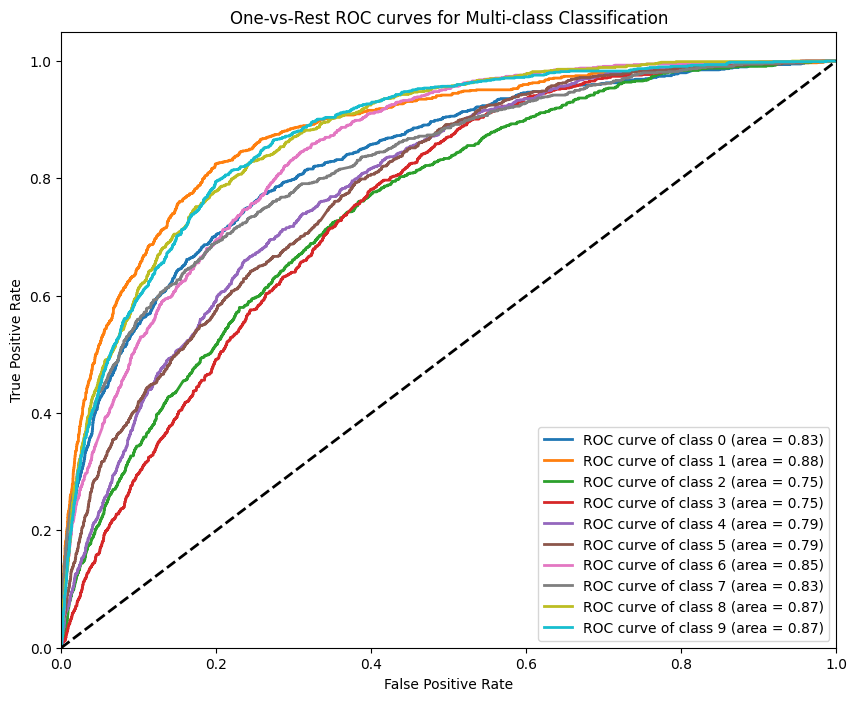

ROC AUC scores per class:
Class 0: 0.83
Class 1: 0.88
Class 2: 0.75
Class 3: 0.75
Class 4: 0.79
Class 5: 0.79
Class 6: 0.85
Class 7: 0.83
Class 8: 0.87
Class 9: 0.87


In [32]:
import numpy as np
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import OneHotEncoder
import matplotlib.pyplot as plt

# Get the number of classes from the predicted probabilities shape
n_classes = y_pred_probs.shape[1]

# One-hot encode true labels for ROC calculation
# Reshape y_true_labels to be 2D for OneHotEncoder
y_true_labels_reshaped = y_true_labels.reshape(-1, 1)
encoder = OneHotEncoder(sparse_output=False)
y_true_one_hot = encoder.fit_transform(y_true_labels_reshaped)

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_one_hot[:, i], y_pred_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot all ROC curves
plt.figure(figsize=(10, 8))
colors = plt.cm.get_cmap('tab10', n_classes) # Get a colormap for distinct colors
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], color=colors(i),
             lw=2, label='ROC curve of class {0} (area = {1:0.2f})'.format(i, roc_auc[i]))

plt.plot([0, 1], [0, 1], 'k--', lw=2) # Diagonal random classifier line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('One-vs-Rest ROC curves for Multi-class Classification')
plt.legend(loc="lower right")
plt.show()

print("ROC AUC scores per class:")
for i in range(n_classes):
    print(f"Class {i}: {roc_auc[i]:.2f}")
